# Notebook 04 — BERT Classification + BART Summarization

This notebook fine-tunes BERT for sentiment classification and uses BART to summarize grouped tweets.

**Targets:**
- BERT: Accuracy ≥ 91%, Macro F1 ≥ 0.90
- BART: ROUGE-L ≥ 0.40

**Steps:**
1. Load and tokenize data with BERT tokenizer
2. Fine-tune `bert-base-uncased`
3. Evaluate classification metrics
4. Group tweets by predicted sentiment
5. Generate BART summaries and score with ROUGE

In [7]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    BartForConditionalGeneration, BartTokenizerFast,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve


In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Load Data

In [3]:
df = load_dataset('training.1600000.processed.noemoticon.csv', sample_size=20000)

## 2. Tokenize with BERT Tokenizer

In [4]:
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 64
tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL)
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }
X = df['text'].tolist()
y = df['label'].tolist()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 16,000 | Val: 2,000 | Test: 2,000


## 3. Fine-Tune BERT

In [5]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2).to(DEVICE)
EPOCHS       = 2
optimizer    = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps)
train_losses, val_losses = [], []
print(f'Total batches per epoch: {len(train_loader)}')
print('Ready to train.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total batches per epoch: 500
Ready to train.


In [6]:
for epoch in range(EPOCHS):
    # --- Training ---
    bert_model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        if batch_idx % 20 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
    avg_train = total_loss / len(train_loader)
    # --- Validation ---
    bert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            val_loss += bert_model(**batch).loss.item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

bert_model.save_pretrained('models/bert_sentiment')
tokenizer.save_pretrained('models/bert_sentiment')
plot_learning_curve(train_losses, val_losses, model_name='BERT', save_path='results/bert_learning_curve.png')
print('Training complete and model saved.')

Epoch 1, Batch 0/500, Loss: 0.8281
Epoch 1, Batch 20/500, Loss: 0.6720
Epoch 1, Batch 40/500, Loss: 0.6693
Epoch 1, Batch 60/500, Loss: 0.5431
Epoch 1, Batch 80/500, Loss: 0.6292
Epoch 1, Batch 100/500, Loss: 0.4942
Epoch 1, Batch 120/500, Loss: 0.4285
Epoch 1, Batch 140/500, Loss: 0.5575
Epoch 1, Batch 160/500, Loss: 0.5050
Epoch 1, Batch 180/500, Loss: 0.5023
Epoch 1, Batch 200/500, Loss: 0.3557
Epoch 1, Batch 220/500, Loss: 0.3211
Epoch 1, Batch 240/500, Loss: 0.3695
Epoch 1, Batch 260/500, Loss: 0.3911
Epoch 1, Batch 280/500, Loss: 0.4881
Epoch 1, Batch 300/500, Loss: 0.4785
Epoch 1, Batch 320/500, Loss: 0.3816
Epoch 1, Batch 340/500, Loss: 0.5652
Epoch 1, Batch 360/500, Loss: 0.3882
Epoch 1, Batch 380/500, Loss: 0.4531
Epoch 1, Batch 400/500, Loss: 0.4730
Epoch 1, Batch 420/500, Loss: 0.3208
Epoch 1, Batch 440/500, Loss: 0.4290
Epoch 1, Batch 460/500, Loss: 0.4911
Epoch 1, Batch 480/500, Loss: 0.3426
Epoch 1/2 | Train Loss: 0.4717 | Val Loss: 0.3831
Epoch 2, Batch 0/500, Loss: 0.5

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'plot_learning_curve' is not defined

In [8]:
print('Training complete and model saved.')

Training complete and model saved.


## 4. Evaluate BERT on Test Set

Number of test batches: 63
Finished batch 0/63
Finished batch 10/63
Finished batch 20/63
Finished batch 30/63
Finished batch 40/63
Finished batch 50/63
Finished batch 60/63

  BERT (Test) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83       994
    Positive       0.84      0.81      0.82      1006

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000

Matthews Correlation Coefficient (MCC): 0.6535
ROC-AUC Score: 0.9145
Macro F1-Score: 0.8265


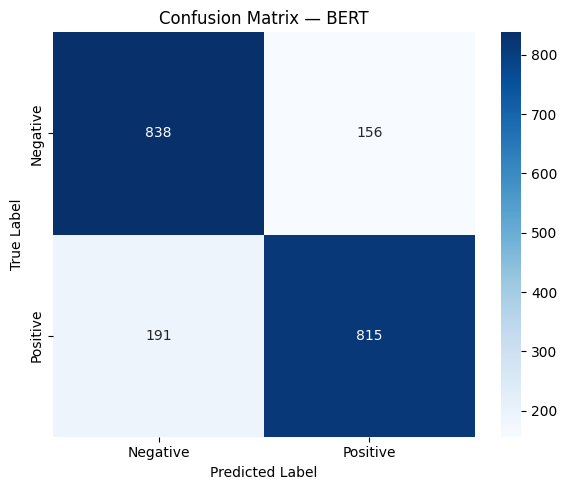

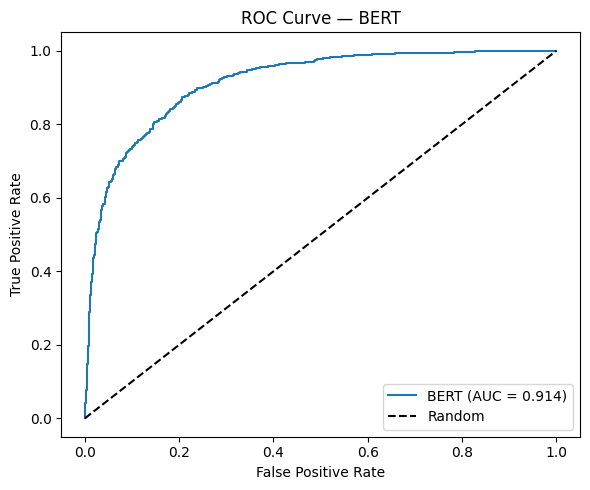

In [9]:
bert_model.eval()
all_preds, all_probs, all_labels = [], [], []
print("Number of test batches:", len(test_loader))
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        labels = batch.pop('labels').cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = bert_model(**batch).logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = np.argmax(logits.cpu().numpy(), axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)
        if batch_idx % 10 == 0:
            print(f"Finished batch {batch_idx}/{len(test_loader)}")

print_metrics(all_labels, all_preds, all_probs, model_name='BERT (Test)')
plot_confusion_matrix(all_labels, all_preds, model_name='BERT', save_path='results/bert_confusion_matrix.png')
plot_roc_curve(all_labels, all_probs, model_name='BERT', save_path='results/bert_roc_curve.png')
